In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import json
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_json = {
    "username": "itxminoo",
    "key": "KGAT_4c9b6753aeb313fd7be04409838e5992"
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_json, f)
os.chmod('/root/.kaggle/kaggle.json', 600)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("Kaggle configured ✅")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Kaggle configured ✅


In [2]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
print("Downloaded ✅")

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:10<00:00, 77.9MB/s]

Downloaded ✅


In [3]:
import zipfile

print("Extracting... ⏳ This may take 1-2 minutes")
with zipfile.ZipFile('covid19-radiography-database.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/covid_dataset')
print("Extracted ✅")

# Check structure
for root, dirs, files in os.walk('/content/covid_dataset'):
    level = root.replace('/content/covid_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if files and level < 3:
        print(f'{indent}  ({len(files)} files)')

Extracting... ⏳ This may take 1-2 minutes
Extracted ✅
covid_dataset/
  COVID-19_Radiography_Dataset/
    (5 files)
    Normal/
      masks/
      images/
    Lung_Opacity/
      masks/
      images/
    COVID/
      masks/
      images/
    Viral Pneumonia/
      masks/
      images/


In [4]:
base_path = '/content/covid_dataset/COVID-19_Radiography_Dataset'

classes = ['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia']

for class_name in classes:
    img_path = os.path.join(base_path, class_name, 'images')
    count = len(os.listdir(img_path))
    print(f"{class_name}: {count} images")

Normal: 10192 images
COVID: 3616 images
Lung_Opacity: 6012 images
Viral Pneumonia: 1345 images


In [5]:
import cv2
import numpy as np

IMG_SIZE = 150
SAMPLES_PER_CLASS = 600

def load_covid_images(base_path, class_name, limit):
    img_dir = os.path.join(base_path, class_name, 'images')
    files = os.listdir(img_dir)[:limit]
    images = []

    for filename in files:
        img_path = os.path.join(img_dir, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)

    return images

print("Loading Normal images...")
normal_imgs = load_covid_images(base_path, 'Normal', SAMPLES_PER_CLASS)

print("Loading COVID images...")
covid_imgs = load_covid_images(base_path, 'COVID', SAMPLES_PER_CLASS//3)

print("Loading Lung_Opacity images...")
opacity_imgs = load_covid_images(base_path, 'Lung_Opacity', SAMPLES_PER_CLASS//3)

print("Loading Viral Pneumonia images...")
viral_imgs = load_covid_images(base_path, 'Viral Pneumonia', SAMPLES_PER_CLASS//3)

# Combine abnormal classes
abnormal_imgs = covid_imgs + opacity_imgs + viral_imgs

# Create labels
X = np.array(normal_imgs + abnormal_imgs, dtype=np.float32) / 255.0
y = np.array([0]*len(normal_imgs) + [1]*len(abnormal_imgs))

print(f"\nTotal images: {len(X)}")
print(f"Normal: {(y==0).sum()}, Abnormal: {(y==1).sum()}")

Loading Normal images...
Loading COVID images...
Loading Lung_Opacity images...
Loading Viral Pneumonia images...

Total images: 1200
Normal: 600, Abnormal: 600


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train - Normal: {(y_train==0).sum()}, Abnormal: {(y_train==1).sum()}")
print(f"Test - Normal: {(y_test==0).sum()}, Abnormal: {(y_test==1).sum()}")

Train: 960 | Test: 240
Train - Normal: 480, Abnormal: 480
Test - Normal: 120, Abnormal: 120


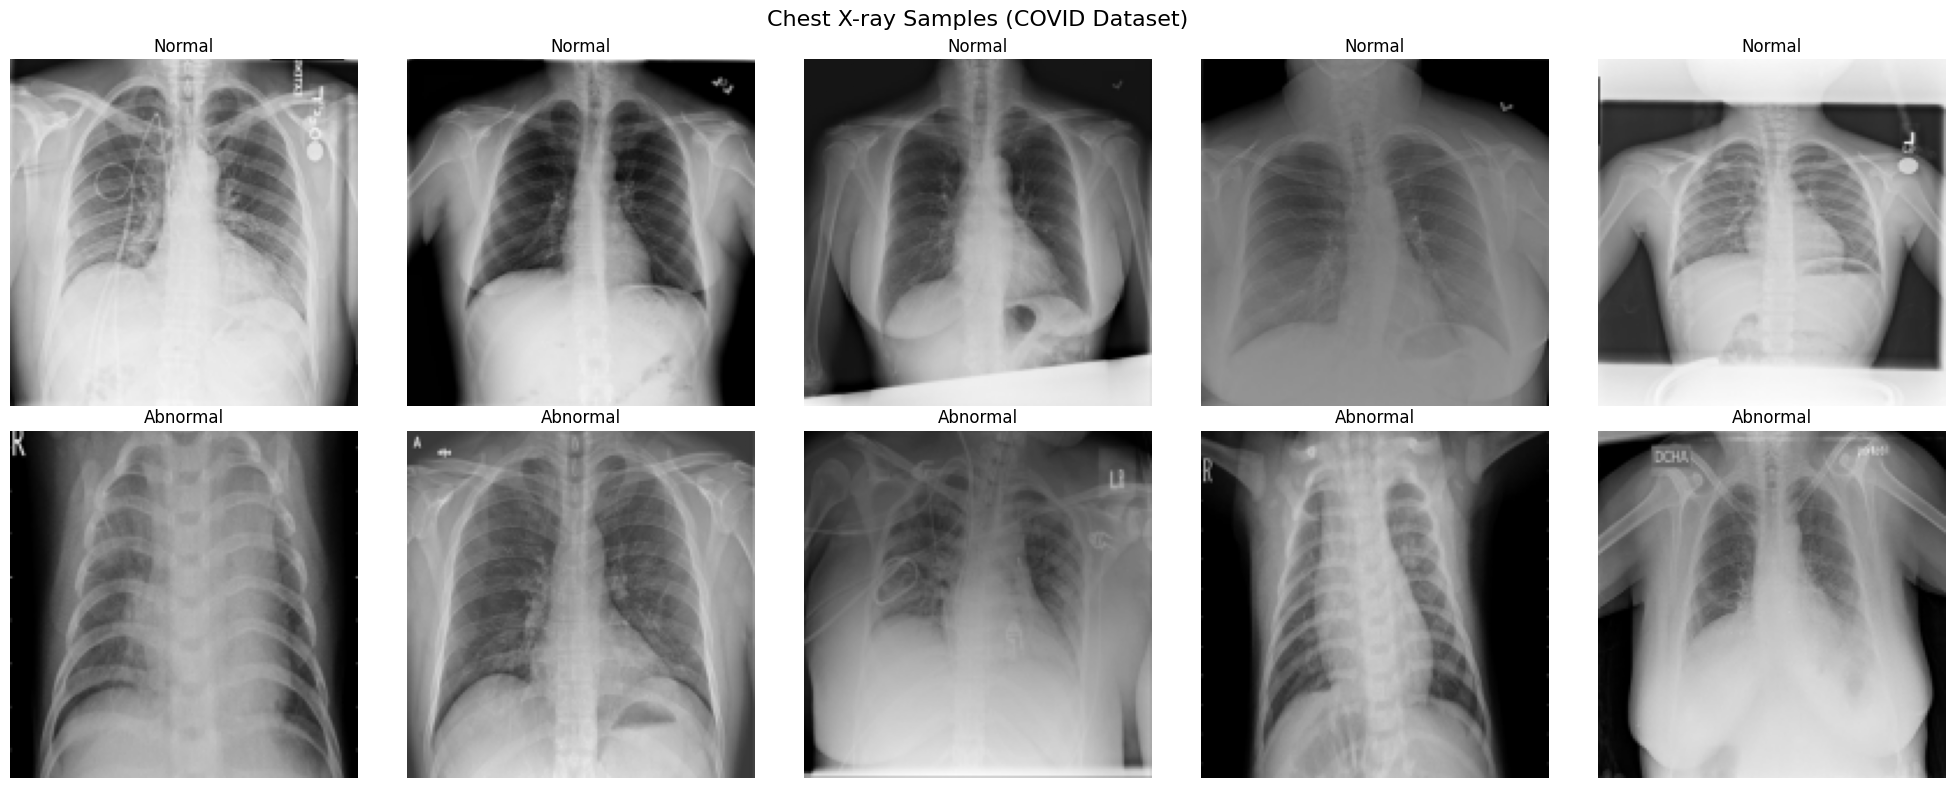

Saved! ✅


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

normal_idx = np.where(y_train==0)[0][:5]
abnormal_idx = np.where(y_train==1)[0][:5]

for i, idx in enumerate(normal_idx):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

for i, idx in enumerate(abnormal_idx):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Abnormal')
    axes[1, i].axis('off')

plt.suptitle('Chest X-ray Samples (COVID Dataset)', fontsize=16)
plt.tight_layout()
plt.savefig('covid_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! ✅")

In [8]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

def build_covid_cnn(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_covid_cnn()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("CNN built ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN built ✅


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

print("Training started... ⏳")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=callbacks
)
print("Training complete! ✅")

Training started... ⏳
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.4906 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 282ms/step - accuracy: 0.4844 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.5115 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.5104 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.5448 - loss: 0.6891 - val_accuracy: 0.5167 - val_loss: 0.6798 - learning_rate: 0.0010
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.5792 - loss: 0.6868 - val_accuracy: 0.5708 - val_loss: 0.6722 - learning_rate: 0.0010
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0

In [10]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n" + "="*40)
print("🎯 FINAL MODEL RESULTS")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print("="*40)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7667 - loss: 0.5129

🎯 FINAL MODEL RESULTS
Test Loss:     0.5129
Test Accuracy: 76.67%


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step
              precision    recall  f1-score   support

      Normal       0.79      0.73      0.76       120
    Abnormal       0.75      0.80      0.77       120

    accuracy                           0.77       240
   macro avg       0.77      0.77      0.77       240
weighted avg       0.77      0.77      0.77       240



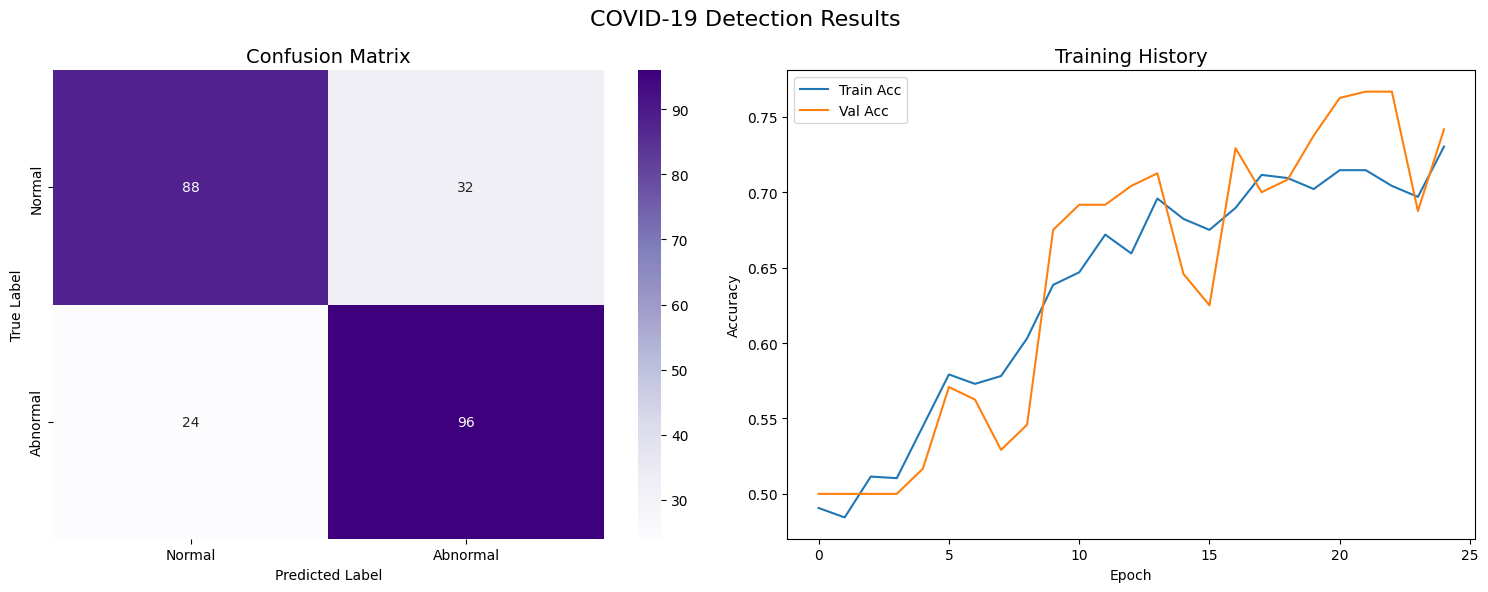

Results saved! ✅


In [11]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
    target_names=['Normal', 'Abnormal']))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
    cmap='Purples',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Training History', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('COVID-19 Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('covid_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [12]:
model.save('covid_model.h5')
print("✅ Model saved")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('covid_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite size: {len(tflite_model)/1024/1024:.2f} MB")

✅ Model saved
Saved artifact at '/tmp/tmpjx9atrvv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134678940331152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940331920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940334032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940332688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940333456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940334800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940331344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940333072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940334608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678940335760: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ 

In [15]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

def build_covid_cnn(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_covid_cnn()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Original CNN rebuilt ✅")

Original CNN rebuilt ✅


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

print("Retraining original CNN... ⏳")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=callbacks
)
print("Training complete! ✅")

Retraining original CNN... ⏳
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.5094 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.5156 - loss: 0.6925 - val_accuracy: 0.5167 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.5115 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6884 - learning_rate: 0.0010
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.5437 - loss: 0.6898 - val_accuracy: 0.6125 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.5625 - loss: 0.6821 - val_accuracy: 0.6042 - val_loss: 0.6712 - learning_rate: 0.0010
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accu

In [17]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n" + "="*40)
print("🎯 FINAL MODEL RESULTS")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print("="*40)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7583 - loss: 0.5103

🎯 FINAL MODEL RESULTS
Test Loss:     0.5103
Test Accuracy: 75.83%


In [18]:
model.save('covid_model.h5')
print("✅ Model saved")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('covid_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite size: {len(tflite_model)/1024/1024:.2f} MB")

✅ Model saved
Saved artifact at '/tmp/tmpy2u3543_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134678600823632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600815184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600824976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600813264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600822672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600823056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600822864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600825552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600822288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134678600822480: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ 

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
              precision    recall  f1-score   support

      Normal       0.80      0.68      0.74       120
    Abnormal       0.72      0.83      0.78       120

    accuracy                           0.76       240
   macro avg       0.76      0.76      0.76       240
weighted avg       0.76      0.76      0.76       240



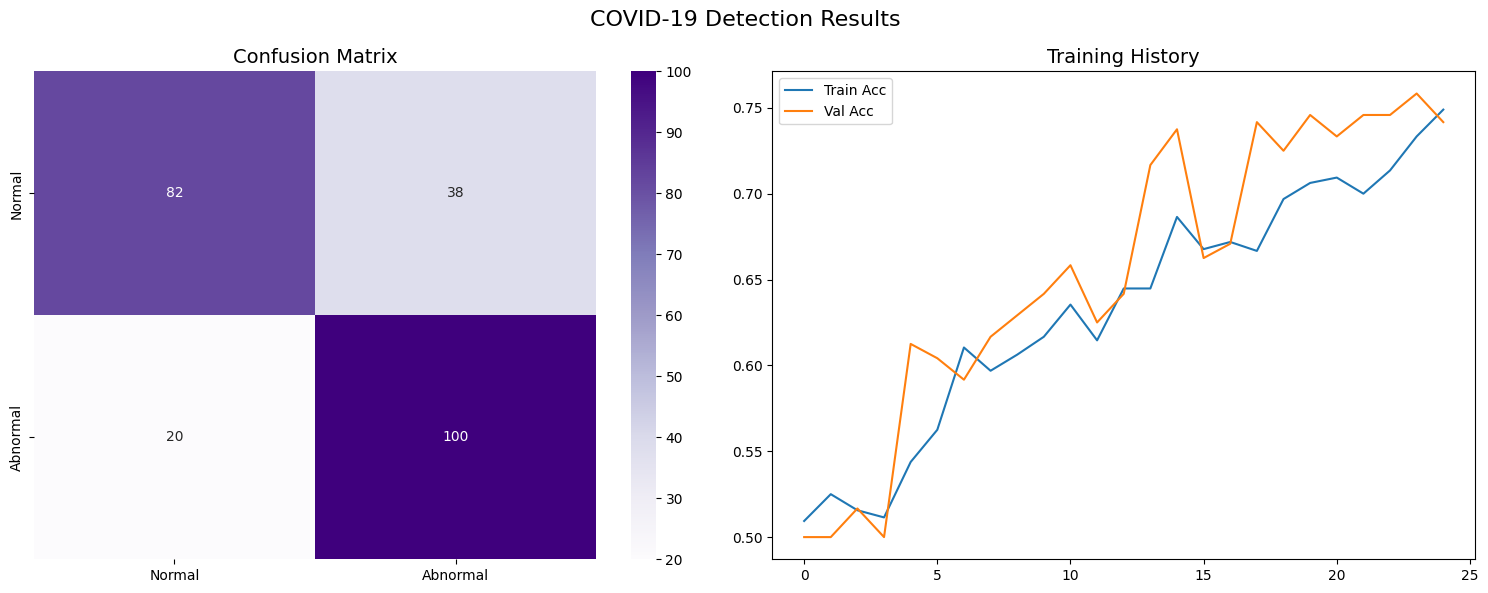

Saved! ✅


In [19]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
    target_names=['Normal', 'Abnormal']))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
    cmap='Purples',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'])
axes[0].set_title('Confusion Matrix', fontsize=14)

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Training History', fontsize=14)
axes[1].legend()

plt.suptitle('COVID-19 Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('covid_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! ✅")

In [20]:
from google.colab import files

files.download('covid_samples.png')
files.download('covid_results.png')
files.download('covid_model.tflite')
print("All downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded! ✅
